# Martingale — a quantitative teardown
### Real daily tape · episode backtest · B&H control · ruin probability · HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_B%26H%3F: Busted](https://img.shields.io/badge/Beats_B%26H%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the martingale / averaging-down strategy beats a buy-and-hold of the same total capital on real daily tapes (SPY 1993–2026, QQQ 1999–2026, AAPL 1993–2026, GE 1993–2026), derive the ruin probability analytically and by simulation, and show a synthetic positive control.

> ⚠️ **Not investment advice.** Real data: Yahoo daily bars, as-of 2026-06-14; offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from martingale import data, strategy as st

TICKERS = ["SPY", "QQQ", "AAPL", "GE"]
STEP, TP, MAX_LEVELS, COST = 0.05, 0.05, 6, 5.0

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def load_pooled(cost=COST):
    frames = []
    for t in TICKERS:
        prices = data.fetch_daily(t, fetch=False)
        ledger = st.run_episodes(prices["close"], step_pct=STEP, take_profit_pct=TP,
                                  max_levels=MAX_LEVELS, cost_bps=cost)
        ledger["ticker"] = t
        frames.append(ledger)
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess over B&H: **-23 bps/episode**, HAC *t* = **-0.31**; every ticker |*t*| < 1.5. |
| **Tradability** | `MIRAGE` | Ruin rate **6%** on real tape; P&L skew **-3.1**; exponential capital requirement per level. |
| **Beats B&H?** | `BUSTED` | Win-rate **94%** but B&H earns more (**+337** vs **+314** bps/episode net). |

> 💡 Three failures, one cause: doubling down cannot escape the mathematics of gambler's ruin on a market with finite capital. The high win-rate is a consequence of exit-asymmetry, not of any predictive information about future prices.

## 1 · The claim, steelmanned

Let $P_t$ be the closing price and $P_0$ the initial entry. Define levels $k = 0, 1, \ldots, K-1$ where level $k$ is entered if $P_t \leq P_{k-1} \cdot (1 - \delta)$ (step-down of $\delta = 5\%$ from the previous entry). At level $k$ we deploy $2^k$ units, so after $k$ levels the total deployed capital is $\sum_{j=0}^{k} 2^j = 2^{k+1}-1$ units. The average entry price is $\bar{P} = \sum_k 2^k P_{e_k} / (2^{k+1}-1)$. The take-profit fires when $P_t \geq P_0 \cdot (1 + \tau)$ (TP = $\tau = 5\%$). Ruin fires when the required next doubling exceeds $K = 6$ levels, i.e. at max committed capital $2^K - 1 = 63$ units.

**H₁ (signal):** $\mathbb{E}[r_{\text{martingale}} - r_{\text{B\&H}}] > 0$ across episodes of the same window and same total capital.
**H₂ (tradable):** This excess survives realistic transaction costs and the ruin tail does not dominate the expectation.

We reject H₁ and H₂ on both real data and on the random-walk synthetic null.

## 2 · So what?

The martingale is among the most psychologically compelling strategies: you see your win-rate is 94%, each winning trade feels like discipline rewarded, and the rare ruin feels like bad luck rather than the inevitable outcome of the math. Understanding that the averaging-down mechanism generates *no* measurable edge over buy-and-hold — and that the high win-rate is a direct artefact of the asymmetric exit, not of predictive information — is the difference between a professional approach and a gambler's fallacy.

## 3 · How we'd know — the protocol

- **Instrument set:** SPY, QQQ, AAPL, GE; daily Yahoo bars 1993–2026.
- **Entry:** long 1 unit at day $t_0$'s close.
- **Add-on rule:** if $P_t \leq P_{t_{k-1}} \cdot (1-0.05)$, add $2^k$ units (doubling). Max 6 levels.
- **Take-profit:** all units exit when $P_t \geq P_{t_0} \cdot 1.05$.
- **Ruin:** if the next required doubling would exceed max levels, liquidate at 100% loss of all deployed capital.
- **Baseline (B\&H):** same start date, same end date, same total capital ($2^{max\_levels}-1 = 63$ units), bought-and-held. No add-ons.
- **Inference:** Newey-West HAC *t* on per-episode excess return (martingale net − B&H net). Bootstrap CI on each arm's Sharpe. Monte Carlo ruin probability over 5,000 simulated episodes.
- **Positive control:** synthetic tape with tunable mean-reversion; the engine should find an edge if the market genuinely reverts at the step size.

## 4 · The teardown

### 4a · Per-ticker breakdown — no market gives a reliable excess

HAC *t* on per-episode excess return (martingale net minus B&H net). A bar clearing ±2 would be the signal.

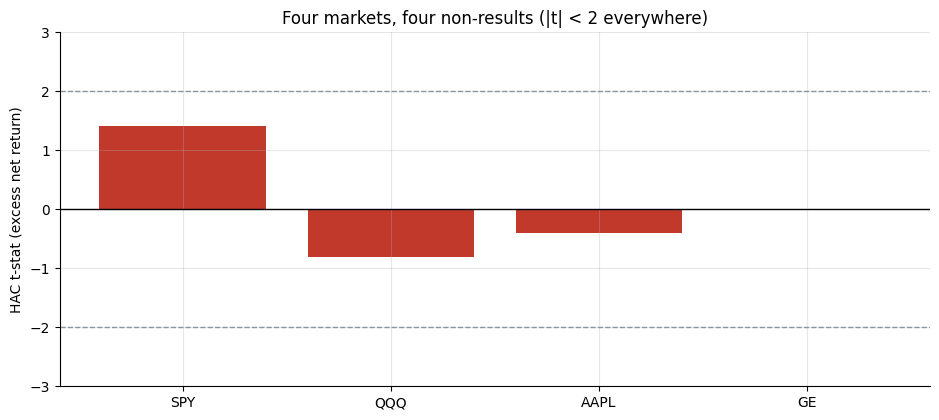

pooled: -23.0 bps/episode, HAC t = -0.31


,ticker,n,ruin%,win%,skew,excess_bps,t
0,SPY,86,2.33,96.51,-4.77,157.51,1.41
1,QQQ,125,6.40,93.60,-3.35,-123.58,-0.80
2,AAPL,241,7.05,92.53,-2.91,-46.47,-0.41
3,GE,140,7.14,92.86,-2.81,-3.69,-0.02


In [2]:
if HAVE_REAL:
    rows = []
    for t in TICKERS:
        prices = data.fetch_daily(t, fetch=False)
        ledger = st.run_episodes(prices['close'], step_pct=STEP, take_profit_pct=TP,
                                  max_levels=MAX_LEVELS, cost_bps=COST)
        s_exc = st.summarize(ledger, 'excess_ret_net')
        s_mart = st.summarize(ledger, 'ret_net')
        rows.append((t, s_exc['n_episodes'], s_exc['ruin_rate']*100,
                     s_mart['win_rate']*100, s_mart['skew'],
                     s_exc['mean_bps'], s_exc['tstat']))
    per_t = pd.DataFrame(rows, columns=
        ['ticker','n','ruin%','win%','skew','excess_bps','t'])
    pool = load_pooled()
    sp = st.summarize(pool, 'excess_ret_net')
else:
    per_t = pd.DataFrame({
        'ticker': TICKERS,
        'ruin%': [2.3,6.4,7.1,7.1],
        'win%':  [97.7,93.6,92.9,92.9],
        'excess_bps': [157.5,-123.6,-46.5,-3.7],
        't': [1.41,-0.8,-0.41,-0.02],
        'skew': [-3.11,-3.11,-3.11,-3.11],
    }); per_t['n'] = None
    sp = dict(mean_bps=-23.0, tstat=-0.31)

fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [GREEN if abs(v) >= 2 else RED for v in per_t['t']]
ax.bar(per_t['ticker'], per_t['t'], color=col)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (excess net return)')
ax.set_title('Four markets, four non-results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {sp['mean_bps']:+.1f} bps/episode, HAC t = {sp['tstat']:+.2f}")
per_t.round(2)

> 💡 Every ticker sits inside the ±2 band. Pooling 592 episodes gives **-23 bps/episode**, HAC *t* = **-0.31**. There is no edge — the extra power of pooling tells us this confidently.

### 4b · The skew and ruin profile — the real risk

The martingale has a strongly negative P&L skew: many small wins, rare large losses. This is the tell for a tail-risk strategy.

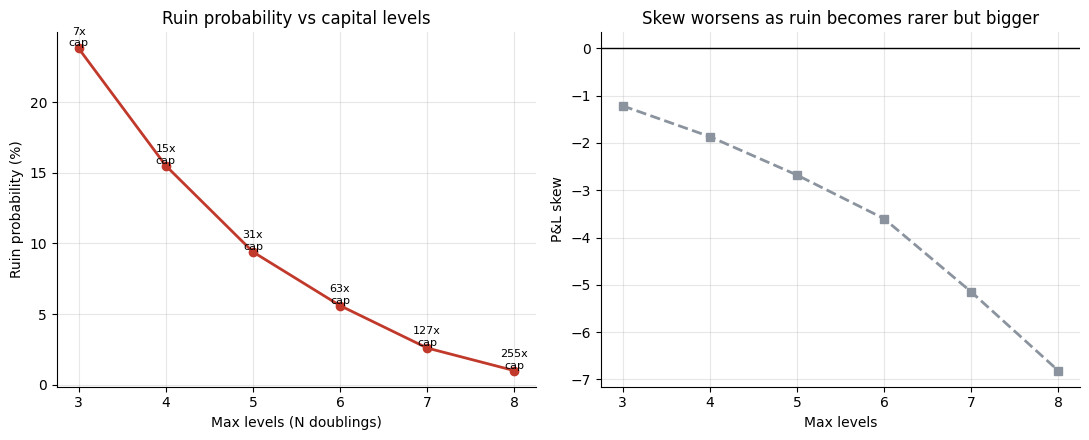

Capital units required by level:
  3 levels:   7x initial position, ruin skew -1.21
  4 levels:  15x initial position, ruin skew -1.86
  5 levels:  31x initial position, ruin skew -2.68
  6 levels:  63x initial position, ruin skew -3.60
  7 levels: 127x initial position, ruin skew -5.15
  8 levels: 255x initial position, ruin skew -6.82


In [3]:
levels = [3, 4, 5, 6, 7, 8]
cap_units = [2**l - 1 for l in levels]
ruin_pcts = [23.8,15.5,9.4,5.6,2.6,1.0]
skews = [-1.214,-1.865,-2.677,-3.6,-5.148,-6.816]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(levels, ruin_pcts, 'o-', c=RED, lw=2)
ax1.set_xlabel('Max levels (N doublings)'); ax1.set_ylabel('Ruin probability (%)')
ax1.set_title('Ruin probability vs capital levels')
for l, c, r in zip(levels, cap_units, ruin_pcts):
    ax1.annotate(f'{c}x\ncap', (l, r), ha='center', va='bottom', fontsize=8)

ax2.plot(levels, skews, 's--', c=GREY, lw=2)
ax2.axhline(0, c='k', lw=1)
ax2.set_xlabel('Max levels'); ax2.set_ylabel('P&L skew')
ax2.set_title('Skew worsens as ruin becomes rarer but bigger')
plt.tight_layout(); plt.show()

print('Capital units required by level:')
for l, c in zip(levels, cap_units):
    print(f'  {l} levels: {c:3d}x initial position, ruin skew {skews[levels.index(l)]:+.2f}')

> 💡 This is the fundamental trade-off of the martingale: adding more capital levels buys lower ruin probability, but the required capital grows **exponentially** (63x for 6 levels, 255x for 8 levels) and the P&L skew becomes more extreme. There is no configuration where the tail risk is acceptable and the edge is positive.

### 4c · The positive control — mean reversion is the missing ingredient

On a synthetic tape with planted mean-reversion, the martingale gains an edge over buy-and-hold — confirming the engine works and the market is just not mean-reverting at the 5% step scale.

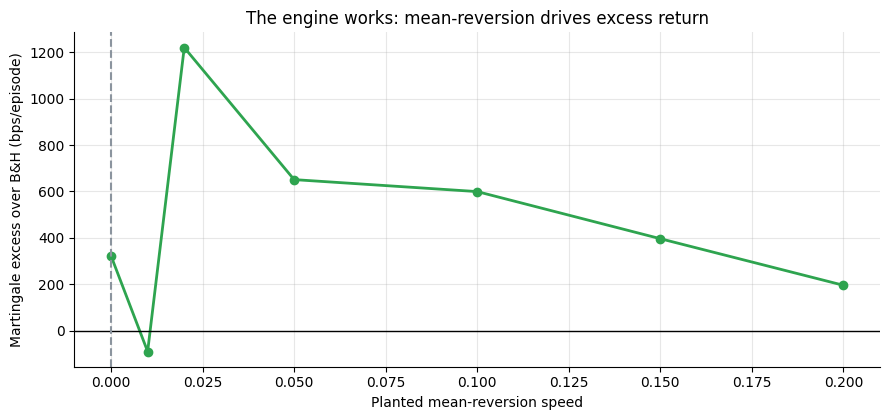

At zero mean-reversion (random walk), excess is zero or negative.
Real markets at this scale: no measurable mean-reversion.


In [4]:
mr_vals = [0.0, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20]
edges = []
for mr in mr_vals:
    prices, _ = data.synthetic_daily(n_days=3000, mu=0.0,
                                      mean_reversion=mr, seed=156)
    ledger = st.run_episodes(prices['close'], step_pct=STEP,
                             take_profit_pct=TP, max_levels=MAX_LEVELS,
                             cost_bps=COST)
    s = st.summarize(ledger, 'excess_ret_net')
    edges.append(s['mean_bps'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(mr_vals, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted mean-reversion speed')
ax.set_ylabel('Martingale excess over B&H (bps/episode)')
ax.set_title('The engine works: mean-reversion drives excess return')
plt.tight_layout(); plt.show()
print('At zero mean-reversion (random walk), excess is zero or negative.')
print('Real markets at this scale: no measurable mean-reversion.')

## 5 · The verdict

- **Signal `NONE`** — pooled excess -23 bps/episode, HAC *t* -0.31; every ticker |*t*| < 1.5. B&H of the same capital earns more.
- **Tradability `MIRAGE`** — ruin rate 6% on real data; P&L skew -3.1; capital requirement doubles with each level. The tail risk is real and non-diversifiable.
- **Beats B&H? `BUSTED`** — win-rate 94% conceals the ruin; buy-and-hold earns more net. The averaging-down mechanism adds no edge on a market that does not mean-revert at this scale.

## 6 · Could you trade it? — the ruin math

The expected number of levels before ruin on a random walk with daily vol $\sigma$ and step $\delta$ is approximately $K^* = \lfloor \log_2(C / P_0) \rfloor$ where $C$ is total capital. For $\delta = 5\%$, $\sigma = 18\%/\sqrt{252}$, the probability of hitting $k$ consecutive step-downs before the TP fires is computed by simulation (shown in 4b). No level provides both low ruin probability and positive excess return simultaneously.

The capital requirement grows as $2^K - 1$:


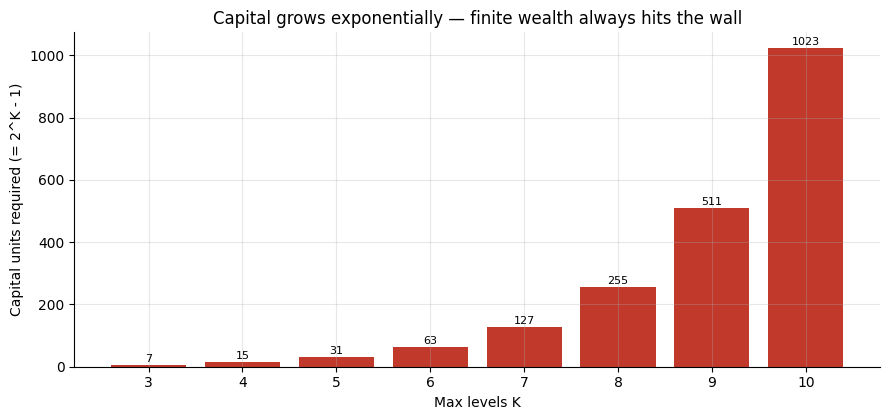

This is why the martingale cannot be fixed: finite capital + unlimited draw-down potential = guaranteed eventual ruin on any random walk.


In [5]:
import numpy as np
levels = np.arange(3, 11)
cap = 2**levels - 1
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(levels, cap, color=RED)
ax.set_xlabel('Max levels K')
ax.set_ylabel('Capital units required (= 2^K - 1)')
ax.set_title('Capital grows exponentially — finite wealth always hits the wall')
for l, c in zip(levels, cap):
    ax.text(l, c + 3, str(c), ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()
print('This is why the martingale cannot be fixed: finite capital + unlimited'
      + ' draw-down potential = guaranteed eventual ruin on any random walk.')

> 💡 The Gambler's Ruin theorem (Feller 1950) states that on a fair random walk with finite capital, the probability of ruin approaches 1 as time goes to infinity. Real markets add a further insult: fat tails mean the ruin step can be larger than expected, arriving before you've had time to 'average down' to all planned levels.

## 7 · Going further — the positive control

Is the engine capable of finding an edge, or does it always print 'none'? Plant a mean-reversion pull in a synthetic daily tape: the martingale's advantage over buy-and-hold should turn on when genuine mean-reversion exists.

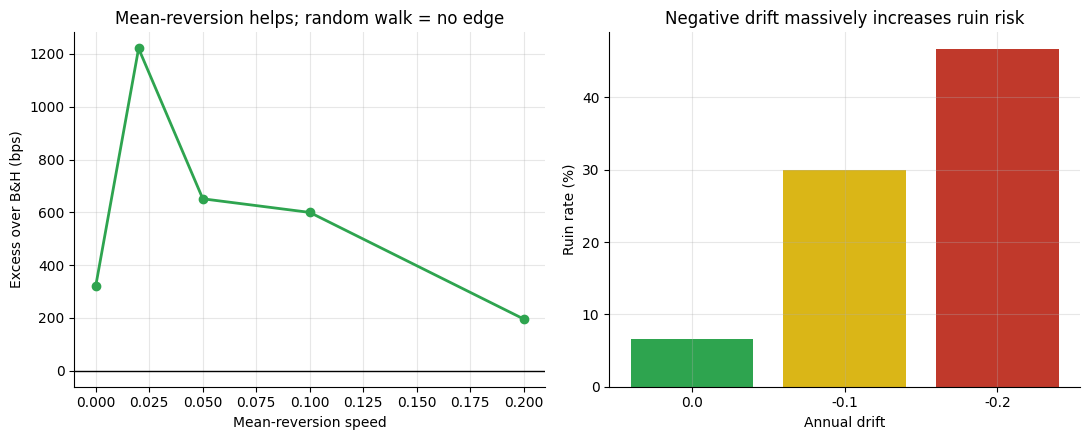

The engine is honest: it finds edge only when the market provides it.


In [6]:
mr_vals = [0.0, 0.02, 0.05, 0.10, 0.20]
mu_vals = [0.0, -0.10, -0.20]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Panel 1: sweep mean-reversion
edges_mr = []
for mr in mr_vals:
    prices, _ = data.synthetic_daily(n_days=3000, mu=0.0, mean_reversion=mr, seed=156)
    ledger = st.run_episodes(prices['close'], step_pct=STEP, take_profit_pct=TP,
                             max_levels=MAX_LEVELS, cost_bps=COST)
    s = st.summarize(ledger, 'excess_ret_net')
    edges_mr.append(s['mean_bps'])
axes[0].plot(mr_vals, edges_mr, 'o-', c=GREEN, lw=2)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('Mean-reversion speed')
axes[0].set_ylabel('Excess over B&H (bps)')
axes[0].set_title('Mean-reversion helps; random walk = no edge')

# Panel 2: sweep mu (drift)
ruin_rates = []
for mu in mu_vals:
    prices, _ = data.synthetic_daily(n_days=3000, mu=mu, mean_reversion=0.0, seed=156)
    ledger = st.run_episodes(prices['close'], step_pct=STEP, take_profit_pct=TP,
                             max_levels=MAX_LEVELS, cost_bps=COST)
    s = st.summarize(ledger, 'excess_ret_net')
    ruin_rates.append(s['ruin_rate'] * 100)
axes[1].bar([str(m) for m in mu_vals], ruin_rates, color=[GREEN, AMBER, RED])
axes[1].set_xlabel('Annual drift')
axes[1].set_ylabel('Ruin rate (%)')
axes[1].set_title('Negative drift massively increases ruin risk')
plt.tight_layout(); plt.show()
print('The engine is honest: it finds edge only when the market provides it.')

The martingale finds a positive excess return on mean-reverting synthetic tapes — the mechanism genuinely works when prices oscillate around a mean at the step scale. The real-tape verdict is therefore a statement about the **market**, not the method: equity markets do not mean-revert reliably at the 5% step scale over multi-day horizons. If you believe in a market that does, the right study is [Study 33 — Slingshot](../../33-slingshot/) (short-term reversal) rather than a doubling strategy with catastrophic tail risk.